In [1]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.metrics import r2_score, mean_squared_error

In [2]:
data = pd.read_csv("/Users/nidhishgupta/Desktop/GridlockChallenge/data/processed/training_data.csv")

In [3]:
data

,Index,geohash,day,timestamp,demand,NumberofLanes,Temperature,hour,minute,minute_of_day,...,demand_lag_1,demand_lag_2,traffic_cluster_id,Weather_Rainy,Weather_Snowy,Weather_Sunny,RoadType_Residential,RoadType_Street,LargeVehicles_Not Allowed,Landmarks_Yes
0,36776,qp02yc,48,10:30,0.046790,1,22.809028,10,30,630,...,0.047760,0.047760,15,0,0,1,1,0,1,0
1,37683,qp02yc,48,10:45,0.021158,1,16.543659,10,45,645,...,0.046790,0.047760,15,0,0,0,1,0,1,0
2,2911,qp02yc,48,1:0,0.005397,3,11.299877,1,0,60,...,0.021158,0.046790,15,1,0,0,1,0,0,1
3,8010,qp02yc,48,2:30,0.012944,2,32.142120,2,30,150,...,0.005397,0.021158,15,0,0,1,1,0,1,1
4,8905,qp02yc,48,2:45,0.025961,1,15.811063,2,45,165,...,0.012944,0.005397,15,0,0,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77294,32309,qp0dnj,48,9:0,0.023207,2,8.420461,9,0,540,...,0.033207,0.021213,9,1,0,0,1,0,1,1
77295,33179,qp0dnj,48,9:15,0.028085,1,28.507294,9,15,555,...,0.023207,0.033207,9,0,0,1,1,0,1,0
77296,34062,qp0dnj,48,9:30,0.049272,1,2.985736,9,30,570,...,0.028085,0.023207,9,0,1,0,1,0,1,0
77297,60798,qp0dnn,48,19:45,0.007751,2,13.101840,19,45,1185,...,0.047760,0.047760,9,1,0,0,1,0,1,1


In [4]:
data.columns

Index(['Index', 'geohash', 'day', 'timestamp', 'demand', 'NumberofLanes',
       'Temperature', 'hour', 'minute', 'minute_of_day', 'time_sin',
       'time_cos', 'latitude', 'longitude', 'demand_lag_1', 'demand_lag_2',
       'traffic_cluster_id', 'Weather_Rainy', 'Weather_Snowy', 'Weather_Sunny',
       'RoadType_Residential', 'RoadType_Street', 'LargeVehicles_Not Allowed',
       'Landmarks_Yes'],
      dtype='object')

In [5]:
unused_columns = ['Index', 'geohash', 'day', 'timestamp', 'hour', 'minute', 'demand']

In [6]:
y = data['demand']

In [7]:
X = data.drop(columns=unused_columns)

In [8]:
X

,NumberofLanes,Temperature,minute_of_day,time_sin,time_cos,latitude,longitude,demand_lag_1,demand_lag_2,traffic_cluster_id,Weather_Rainy,Weather_Snowy,Weather_Sunny,RoadType_Residential,RoadType_Street,LargeVehicles_Not Allowed,Landmarks_Yes
0,1,22.809028,630,0.382683,-0.923880,-5.484924,90.653687,0.047760,0.047760,15,0,0,1,1,0,1,0
1,1,16.543659,645,0.321439,-0.946930,-5.484924,90.653687,0.046790,0.047760,15,0,0,0,1,0,1,0
2,3,11.299877,60,0.258819,0.965926,-5.484924,90.653687,0.021158,0.046790,15,1,0,0,1,0,0,1
3,2,32.142120,150,0.608761,0.793353,-5.484924,90.653687,0.005397,0.021158,15,0,0,1,1,0,1,1
4,1,15.811063,165,0.659346,0.751840,-5.484924,90.653687,0.012944,0.005397,15,0,0,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77294,2,8.420461,540,0.707107,-0.707107,-5.243225,90.972290,0.033207,0.021213,9,1,0,0,1,0,1,1
77295,1,28.507294,555,0.659346,-0.751840,-5.243225,90.972290,0.023207,0.033207,9,0,0,1,1,0,1,0
77296,1,2.985736,570,0.608761,-0.793353,-5.243225,90.972290,0.028085,0.023207,9,0,1,0,1,0,1,0
77297,2,13.101840,1185,-0.896873,0.442289,-5.237732,90.972290,0.047760,0.047760,9,1,0,0,1,0,1,1


In [9]:
y

0        0.046790
1        0.021158
2        0.005397
3        0.012944
4        0.025961
           ...   
77294    0.023207
77295    0.028085
77296    0.049272
77297    0.007751
77298    0.000738
Name: demand, Length: 77299, dtype: float64

In [10]:
split_idx = int(len(data) * 0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Training shapes: {X_train.shape}, Testing shapes: {X_test.shape}")

Training shapes: (61839, 17), Testing shapes: (15460, 17)


In [11]:
xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    tree_method='hist',
    random_state=42,
    n_jobs=-1
)

In [12]:
print("Training XGBoost model... This might take a moment depending on dataset size.")
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)

Training XGBoost model... This might take a moment depending on dataset size.
[0]	validation_0-rmse:0.09430
[50]	validation_0-rmse:0.02837
[100]	validation_0-rmse:0.02706
[150]	validation_0-rmse:0.02704
[200]	validation_0-rmse:0.02704
[250]	validation_0-rmse:0.02707
[300]	validation_0-rmse:0.02732
[350]	validation_0-rmse:0.02803
[400]	validation_0-rmse:0.02859
[450]	validation_0-rmse:0.02892
[499]	validation_0-rmse:0.02895


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [14]:
# 5. Predict on test data
y_pred = xgb_model.predict(X_test)

# 6. Calculate Metrics
r2 = r2_score(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred)

print("\n--- Model Evaluation Results ---")
print(f"R² Score: {r2:.4f}")
print(f"RMSE:     {rmse:.4f}")


--- Model Evaluation Results ---
R² Score: 0.9003
RMSE:     0.0008


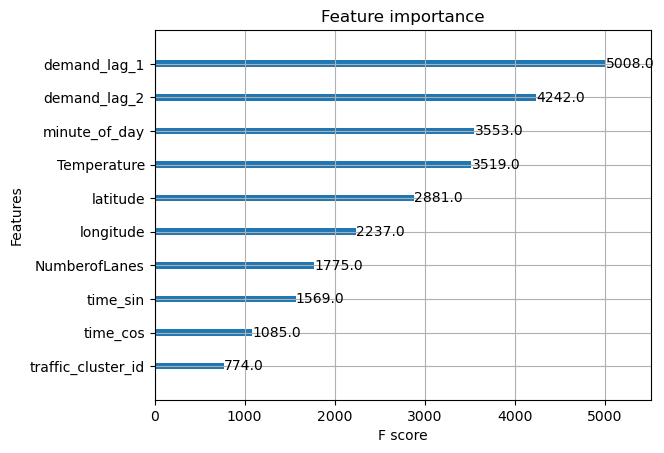

In [15]:
import matplotlib.pyplot as plt

# Plot top 10 most influential features
xgb.plot_importance(xgb_model, max_num_features=10, importance_type='weight')
plt.show()